In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 불필요한 경고문 생략(선택)
import warnings
warnings.filterwarnings('ignore')

# 모든 컬럼 출력설정(선택)
pd.set_option('display.max_columns', None)

df = pd.read_csv('model_df_할인율NaN&음수처리.csv')
df.head(2)

,기획년도,주차,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,판매수량,판매액,평균택가,평균원가,총입고원가,총입고택가,매출원가계,판매택가계,주차별_평균_실판매가,월,월별_평균_실판매가,시즌별_평균_실판매가,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도)
0,2021,2021-01-03,봄_가죽&FUR_가죽점퍼_ZA,ZA,01_시즌,봄,가죽&FUR,가죽점퍼,1:남성,1600,53,52297400,999000,204500,327200000,1598400000,10838500,52947000,987706.0,1,530682.0,455693,986743.0,1.0,53,52297400,10838500,52947000,3.31,0.11,4,0,0,0,3,0,0,0,-9.1
1,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZC,ZC,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,1000,15,590520,39900,7535,7535000,39900000,113025,598500,39368.0,1,30812.0,28709,39368.0,1.0,15,590520,113025,598500,1.50,0.06,4,0,0,0,3,0,0,0,-9.1


In [7]:
df.rename(columns={"주차": "주차_날짜"}, inplace=True)
df["주차_날짜"] = pd.to_datetime(df["주차_날짜"])
df["주차"] = df["주차_날짜"].dt.strftime("%U").astype(int)
df[df['주차']==1].head(2)

,기획년도,주차_날짜,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,판매수량,판매액,평균택가,평균원가,총입고원가,총입고택가,매출원가계,판매택가계,주차별_평균_실판매가,월,월별_평균_실판매가,시즌별_평균_실판매가,실판매가,할인율,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도),주차
0,2021,2021-01-03,봄_가죽&FUR_가죽점퍼_ZA,ZA,01_시즌,봄,가죽&FUR,가죽점퍼,1:남성,1600,53,52297400,999000,204500,327200000,1598400000,10838500,52947000,987706.0,1,530682.0,455693,986743.0,1.0,53,52297400,10838500,52947000,3.31,0.11,4,0,0,0,3,0,0,0,-9.1,1
1,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZC,ZC,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,1000,15,590520,39900,7535,7535000,39900000,113025,598500,39368.0,1,30812.0,28709,39368.0,1.0,15,590520,113025,598500,1.50,0.06,4,0,0,0,3,0,0,0,-9.1,1


In [8]:
columns = ['기획년도', '주차', '평균기온(도)', '할인율', '카테고리','판매수량']
model_df = df[columns]

## 24년 전체

In [20]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# 데이터 분리
train_df = model_df[model_df['기획년도'] < 2024]
test_df = model_df[model_df['기획년도'] == 2024]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

# 전처리: 카테고리 컬럼 원-핫 인코딩
categorical_features = ['카테고리']
numerical_features = ['기획년도', '주차', '평균기온(도)', '할인율']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# 모델 1: Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 모델 2: XGBoost
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

# 학습
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 예측
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# 평가
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} 모델 성능:")
    print(f" - R^2: {r2:.4f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE : {mae:.2f}")
    print('-' * 30)

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


Random Forest 모델 성능:
 - R^2: 0.6479
 - RMSE: 386.86
 - MAE : 208.18
------------------------------
XGBoost 모델 성능:
 - R^2: 0.6658
 - RMSE: 376.85
 - MAE : 228.76
------------------------------


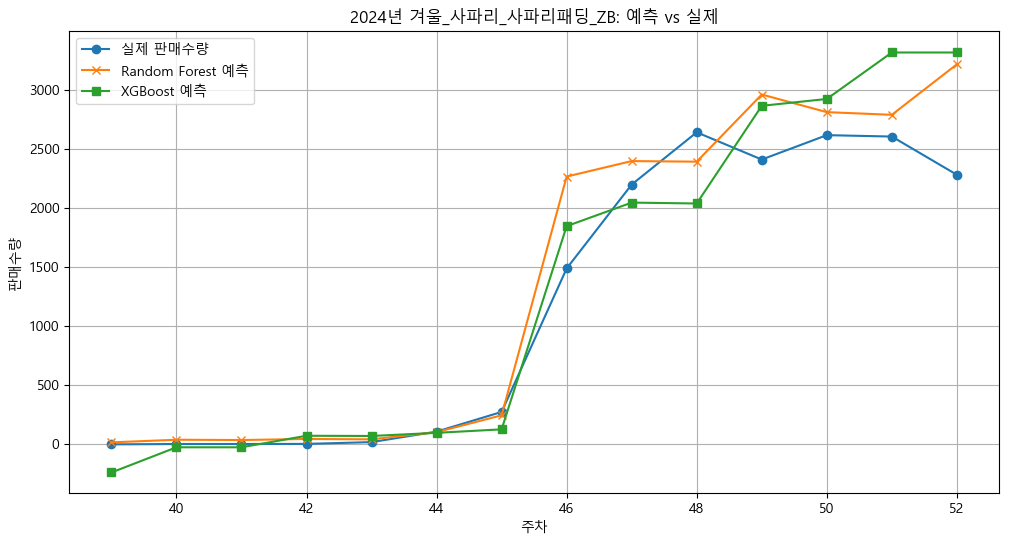

In [ ]:


target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['카테고리'] == '겨울_사파리_패딩사파리_ZB')
]

# 예측용 입력값 (판매수량 제외)
X_target = target_df.drop(columns=['판매수량'])

# 실제값
y_actual = target_df['판매수량']

# 예측값 생성
rf_preds = rf_model.predict(X_target)
xgb_preds = xgb_model.predict(X_target)

# 비교를 위한 데이터프레임 생성
result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

# 정렬 (주차 기준)
result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_사파리_사파리패딩_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# 2024년 11월 데이터만 대상으로 분석
eval_df = model_df[(model_df['기획년도'] == 2024)].copy()

# 예측 수행 (Random Forest 기준)
X_eval = eval_df.drop(columns=['판매수량'])
y_eval = eval_df['판매수량']
eval_df['예측값'] = rf_model.predict(X_eval)

# 지표 계산 함수
def compute_metrics(group):
    mae = mean_absolute_error(group['판매수량'], group['예측값'])
    rmse = mean_squared_error(group['판매수량'], group['예측값'], squared=False)
    r2 = r2_score(group['판매수량'], group['예측값'])
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2})

# 카테고리별 성능 측정
category_metrics = eval_df.groupby('카테고리').apply(compute_metrics).reset_index()
category_metrics

,카테고리,MAE,RMSE,R2
0,가을_니트 셔츠_라운드_ZB,231.336400,263.782849,-0.573892
1,가을_니트 셔츠_티에리_ZB,184.054800,220.450095,-2.257648
2,가을_수트_블레이져(수트)_ZB,133.620500,167.828860,0.391839
3,가을_수트_블레이져(수트)_ZC,48.014000,59.325024,-0.485919
4,가을_수트_수트팬츠_ZB,185.584000,250.869751,-0.290126
...,...,...,...,...
86,여름_팬츠_반바지_ZB,708.569583,915.620784,-15.805061
87,여름_팬츠_반바지_ZG,89.094615,126.035669,-0.028124
88,여름_팬츠_팬츠(일반)_ZA,180.419143,221.574887,0.526756
89,여름_팬츠_팬츠(일반)_ZB,758.063939,1122.872124,0.303281


## 10월 시점

In [18]:
train_df.shape

(8464, 6)

In [9]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# 데이터 분리
train_df = df[df['주차_날짜'] <= '2024-10-27']
test_df = df[(df['주차_날짜'] > '2024-10-27') & (df['주차_날짜']<='2024-11-25')]

train_df = train_df[columns]
test_df = test_df[columns]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

# 전처리: 카테고리 컬럼 원-핫 인코딩
categorical_features = ['카테고리']
numerical_features = ['기획년도', '주차', '평균기온(도)', '할인율']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# 모델 1: Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 모델 2: XGBoost
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

# 학습
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 예측
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# 평가
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} 모델 성능:")
    print(f" - R^2: {r2:.4f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE : {mae:.2f}")
    print('-' * 30)

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


Random Forest 모델 성능:
 - R^2: 0.8549
 - RMSE: 229.81
 - MAE : 146.18
------------------------------
XGBoost 모델 성능:
 - R^2: 0.8335
 - RMSE: 246.16
 - MAE : 173.28
------------------------------


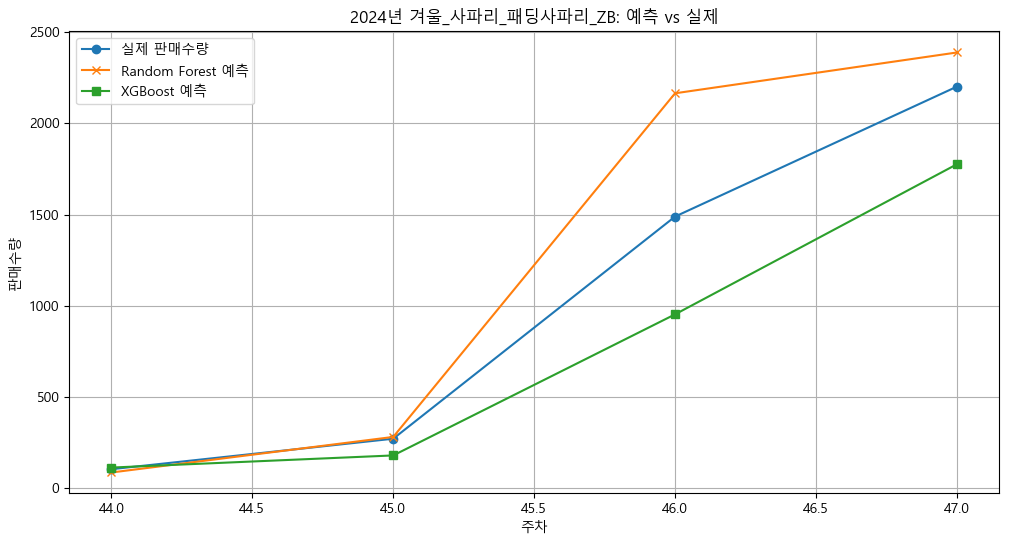

In [10]:
target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['주차'].between(44, 47)) &
    (model_df['카테고리'] == '겨울_사파리_패딩사파리_ZB')
]

# 예측용 입력값 (판매수량 제외)
X_target = target_df.drop(columns=['판매수량'])

# 실제값
y_actual = target_df['판매수량']

# 예측값 생성
rf_preds = rf_model.predict(X_target)
xgb_preds = xgb_model.predict(X_target)

# 비교를 위한 데이터프레임 생성
result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

# 정렬 (주차 기준)
result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_사파리_패딩사파리_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# 2024년 11월 데이터만 대상으로 분석
eval_df = model_df[(model_df['기획년도'] == 2024) & (model_df['주차'].between(44, 47))].copy()

# 예측 수행 (Random Forest 기준)
X_eval = eval_df.drop(columns=['판매수량'])
y_eval = eval_df['판매수량']
eval_df['예측값'] = rf_model.predict(X_eval)

# 지표 계산 함수
def compute_metrics(group):
    mae = mean_absolute_error(group['판매수량'], group['예측값'])
    rmse = mean_squared_error(group['판매수량'], group['예측값'], squared=False)
    r2 = r2_score(group['판매수량'], group['예측값'])
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2})

# 카테고리별 성능 측정
category_metrics = eval_df.groupby('카테고리').apply(compute_metrics).reset_index()
category_metrics

,카테고리,MAE,RMSE,R2
0,가을_니트 셔츠_라운드_ZB,84.4950,85.984036,-1.714428
1,가을_니트 셔츠_티에리_ZB,125.0425,130.294136,-318.183302
2,가을_수트_블레이져(수트)_ZB,103.2825,110.749603,0.090516
3,가을_수트_블레이져(수트)_ZC,49.5950,59.239323,-6.542821
4,가을_수트_수트팬츠_ZB,83.9350,92.446087,0.356076
5,가을_수트_수트팬츠_ZC,19.3650,24.069443,-0.439349
6,가을_스웨터_T-에리_ZA,60.1625,61.796887,-93.292723
7,가을_스웨터_T-에리_ZB,81.2775,83.525413,-63.299490
8,가을_우븐 셔츠_캐쥬얼셔츠_ZB,125.0350,149.728266,-0.485933
9,가을_자켓_싱글재킷_ZA,34.0400,35.804829,-6.518978


### 최적 파라미터 찾기

In [12]:
from sklearn.model_selection import GridSearchCV

# rf_param_grid = {
#     'regressor__n_estimators': [100, 200],
#     'regressor__max_depth': [None, 10, 20],
#     'regressor__min_samples_split': [2, 5],
#     'regressor__min_samples_leaf': [1, 2]
# }

rf_param_grid = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['auto', 'sqrt']
}

rf_grid = GridSearchCV(
    rf_model, 
    rf_param_grid,
    scoring='neg_mean_absolute_error',  # MAE 기준
    cv=3,  # 교차검증 folds 수
    verbose=2,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Params:", rf_grid.best_params_)

# xgb_param_grid = {
#     'regressor__n_estimators': [100, 200],
#     'regressor__max_depth': [3, 6],
#     'regressor__learning_rate': [0.05, 0.1],
#     'regressor__subsample': [0.8, 1.0],
#     'regressor__colsample_bytree': [0.8, 1.0]
# }

xgb_param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7, 10],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__gamma': [0, 1, 5],  # 트리 분할에 필요한 최소 손실 감소
    'regressor__reg_lambda': [1, 5, 10],  # L2 정규화
    'regressor__reg_alpha': [0, 0.5, 1]   # L1 정규화
}

xgb_grid = GridSearchCV(
    xgb_model, 
    xgb_param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_grid.best_params_)


Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best Random Forest Params: {'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 500}
Fitting 3 folds for each of 11664 candidates, totalling 34992 fits
Best XGBoost Params: {'regressor__colsample_bytree': 1.0, 'regressor__gamma': 0, 'regressor__learning_rate': 0.2, 'regressor__max_depth': 10, 'regressor__n_estimators': 200, 'regressor__reg_alpha': 1, 'regressor__reg_lambda': 5, 'regressor__subsample': 0.8}


In [13]:
# 최적 모델로 예측
best_rf_model = rf_grid.best_estimator_
best_xgb_model = xgb_grid.best_estimator_

rf_preds_tuned = best_rf_model.predict(X_test)
xgb_preds_tuned = best_xgb_model.predict(X_test)

# 평가
evaluate_model("Tuned Random Forest", y_test, rf_preds_tuned)
evaluate_model("Tuned XGBoost", y_test, xgb_preds_tuned)

Tuned Random Forest 모델 성능:
 - R^2: 0.8062
 - RMSE: 265.54
 - MAE : 190.81
------------------------------
Tuned XGBoost 모델 성능:
 - R^2: 0.8816
 - RMSE: 207.55
 - MAE : 140.09
------------------------------


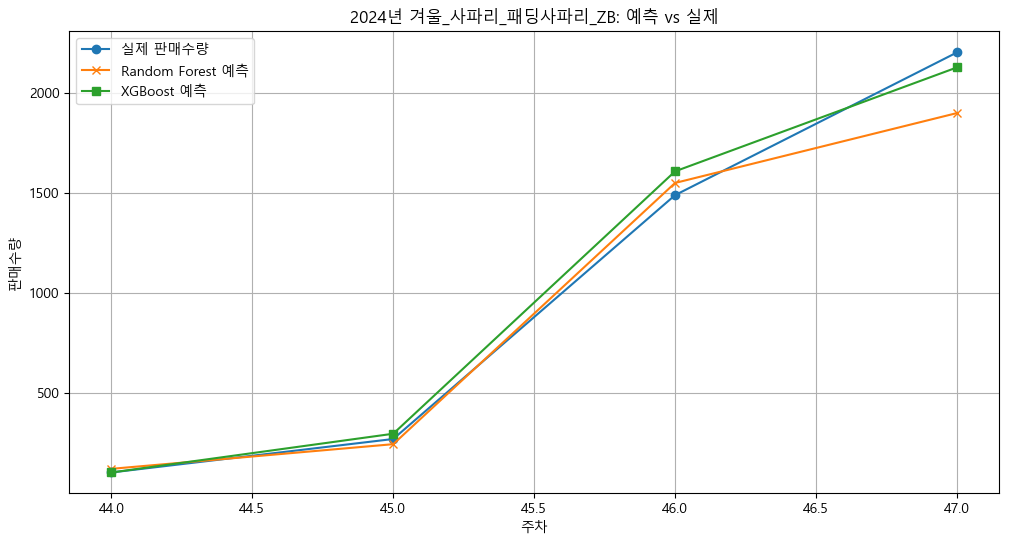

In [14]:
target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['주차'].between(44, 47)) &
    (model_df['카테고리'] == '겨울_사파리_패딩사파리_ZB')
]

# 예측용 입력값 (판매수량 제외)
X_target = target_df.drop(columns=['판매수량'])

# 실제값
y_actual = target_df['판매수량']

# 예측값 생성
rf_preds = best_rf_model.predict(X_target)
xgb_preds = best_xgb_model.predict(X_target)

# 비교를 위한 데이터프레임 생성
result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

# 정렬 (주차 기준)
result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_사파리_패딩사파리_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# 2024년 11월 데이터만 대상으로 분석
eval_df = model_df[(model_df['기획년도'] == 2024) & (model_df['주차'].between(44, 47))].copy()

# 예측 수행 (Random Forest 기준)
X_eval = eval_df.drop(columns=['판매수량'])
y_eval = eval_df['판매수량']
eval_df['예측값'] = best_xgb_model.predict(X_eval)

# 지표 계산 함수
def compute_metrics(group):
    mae = mean_absolute_error(group['판매수량'], group['예측값'])
    rmse = mean_squared_error(group['판매수량'], group['예측값'], squared=False)
    r2 = r2_score(group['판매수량'], group['예측값'])
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2})

# 카테고리별 성능 측정
category_metrics = eval_df.groupby('카테고리').apply(compute_metrics).reset_index()
category_metrics

,카테고리,MAE,RMSE,R2
0,가을_니트 셔츠_라운드_ZB,82.319939,96.629081,-2.428139
1,가을_니트 셔츠_티에리_ZB,170.934752,196.791515,-727.120334
2,가을_수트_블레이져(수트)_ZB,153.234009,176.622405,-1.313143
3,가을_수트_블레이져(수트)_ZC,136.973074,156.421237,-51.590227
4,가을_수트_수트팬츠_ZB,130.820000,144.090197,-0.564323
5,가을_수트_수트팬츠_ZC,133.504219,141.396448,-48.671939
6,가을_스웨터_T-에리_ZA,85.428490,93.580777,-215.231157
7,가을_스웨터_T-에리_ZB,174.568111,178.678833,-293.250002
8,가을_우븐 셔츠_캐쥬얼셔츠_ZB,194.468170,217.809867,-2.144465
9,가을_자켓_싱글재킷_ZA,166.521051,205.898544,-247.646395


## 6월시점

In [55]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# 데이터 분리
train_df = df[df['주차_날짜'] <= '2024-06-30']
test_df = df[(df['주차_날짜'] > '2024-06-30') & (df['주차_날짜']<='2024-07-28')]

train_df = train_df[columns]
test_df = test_df[columns]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

# 전처리: 카테고리 컬럼 원-핫 인코딩
categorical_features = ['카테고리']
numerical_features = ['기획년도', '주차', '평균기온(도)', '할인율']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# 모델 1: Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 모델 2: XGBoost
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

# 학습
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 예측
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# 평가
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} 모델 성능:")
    print(f" - R^2: {r2:.4f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE : {mae:.2f}")
    print('-' * 30)

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


Random Forest 모델 성능:
 - R^2: 0.7038
 - RMSE: 407.15
 - MAE : 204.83
------------------------------
XGBoost 모델 성능:
 - R^2: 0.7406
 - RMSE: 381.04
 - MAE : 212.71
------------------------------


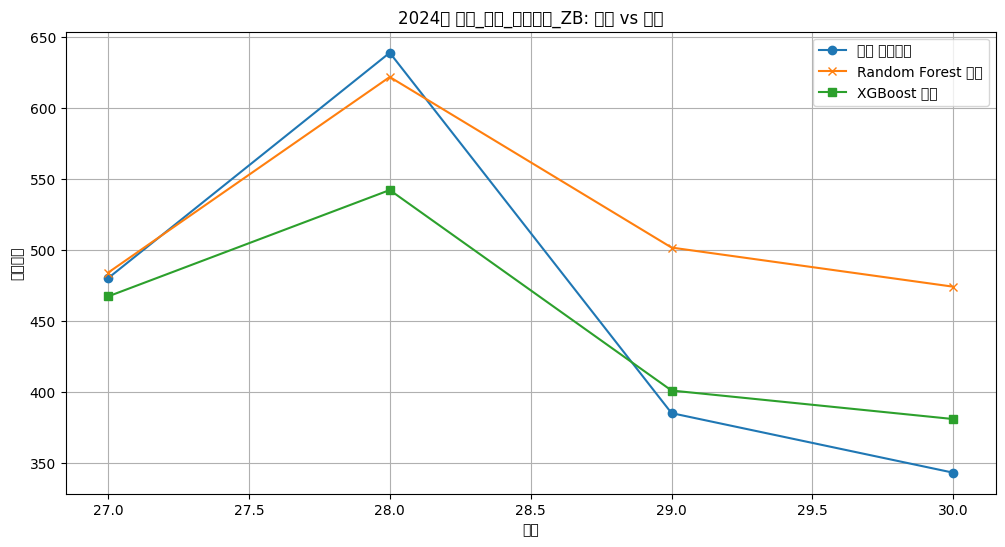

In [56]:
target_df = model_df[
    (model_df['기획년도'] == 2024) &
    (model_df['주차'].between(27, 30)) &
    (model_df['카테고리'] == '사계절_수트_수트팬츠_ZB')
]

# 예측용 입력값 (판매수량 제외)
X_target = target_df.drop(columns=['판매수량'])

# 실제값
y_actual = target_df['판매수량']

# 예측값 생성
rf_preds = rf_model.predict(X_target)
xgb_preds = xgb_model.predict(X_target)

# 비교를 위한 데이터프레임 생성
result_df = X_target.copy()
result_df['실제값'] = y_actual.values
result_df['RandomForest_예측값'] = rf_preds
result_df['XGBoost_예측값'] = xgb_preds

# 정렬 (주차 기준)
result_df = result_df.sort_values(by='주차').reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['주차'], result_df['실제값'], label='실제 판매수량', marker='o')
plt.plot(result_df['주차'], result_df['RandomForest_예측값'], label='Random Forest 예측', marker='x')
plt.plot(result_df['주차'], result_df['XGBoost_예측값'], label='XGBoost 예측', marker='s')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.title('2024년 겨울_점퍼_패딩점퍼_ZB: 예측 vs 실제')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# 2024년 7월 데이터만 대상으로 분석
eval_df = model_df[(model_df['기획년도'] == 2024) & (model_df['주차'].between(27, 30))].copy()

# 예측 수행 (Random Forest 기준)
X_eval = eval_df.drop(columns=['판매수량'])
y_eval = eval_df['판매수량']
eval_df['예측값'] = rf_model.predict(X_eval)

# 지표 계산 함수
def compute_metrics(group):
    mae = mean_absolute_error(group['판매수량'], group['예측값'])
    rmse = mean_squared_error(group['판매수량'], group['예측값'], squared=False)
    r2 = r2_score(group['판매수량'], group['예측값'])
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2})

# 카테고리별 성능 측정
category_metrics = eval_df.groupby('카테고리').apply(compute_metrics).reset_index()
category_metrics

,카테고리,MAE,RMSE,R2
0,가을_니트 셔츠_라운드_ZB,210.022500,279.885534,-261.431866
1,가을_니트 셔츠_티에리_ZB,140.997500,163.201456,-1.038124
2,가을_수트_블레이져(수트)_ZB,62.903333,65.902289,-6.673342
3,가을_수트_블레이져(수트)_ZC,16.773333,17.076305,-0.819974
4,가을_수트_수트팬츠_ZB,72.720000,83.540589,-7.609001
5,가을_수트_수트팬츠_ZC,23.376667,23.464655,-1.037545
6,가을_스웨터_T-에리_ZA,153.700000,212.144751,-1.410799
7,가을_스웨터_T-에리_ZB,225.215000,228.737786,-87.726613
8,가을_우븐 셔츠_캐쥬얼셔츠_ZB,10.617500,10.839870,0.305488
9,가을_팬츠_팬츠(일반)_ZB,42.815000,49.149527,-0.962867


# 강화학습

In [16]:
import gymnasium
print(gymnasium.__version__)

1.0.0


In [17]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class RetailEnv(gym.Env):
    def __init__(self, model, min_discount, max_discount, total_stock, target_ratio, initial_sales, price, temperature_list, cost_per_unit, start_year, start_week, initial_revenue, planning_horizon, category:str):
        super(RetailEnv, self).__init__()

        self.model = model
        self.discount_actions = [i for i in range(min_discount, max_discount + 5, 5)]
        self.action_space = spaces.Discrete(len(self.discount_actions))

        self.observation_space = spaces.Box(
            low=np.array([2021, 0, 0, -10, min_discount, 0, -np.inf, 0]),
            high=np.array([2030, 52, 52, 40, max_discount, np.inf, np.inf, np.inf]),
            dtype=np.float32
        )

        self.start_year = start_year
        self.start_week = start_week
        self.initial_revenue = initial_revenue
        self.planning_horizon = planning_horizon

        self.total_stock = total_stock
        self.target_ratio = target_ratio
        self.initial_sales = initial_sales
        self.price = price

        self.temperature_list = temperature_list
        self.cost_per_unit = cost_per_unit

        self.category = category

        self.reset()

    def reset(self, seed=None, options=None):
        self.year = self.start_year
        self.week = self.start_week
        self.discount = self.discount_actions[0]
        self.cumulative_sales = self.initial_sales
        self.cumulative_revenue = self.initial_revenue
        self.remaining_weeks = self.planning_horizon

        self.final_week = self.week + self.remaining_weeks

        self.target_sales = self.total_stock * self.target_ratio

        return self._get_state(), {}

    def step(self, action_index):
        # 주차를 먼저 업데이트
        self.week += 1

        if self.week > 52:
            self.week = 1
            self.year += 1

        if self.remaining_weeks > 0:
            self.remaining_weeks -= 1

        # 인덱스 계산
        week_idx = min(self.week - 1, len(self.temperature_list) - 1)
        temperature = self.temperature_list[week_idx]

        self.discount = self.discount_actions[action_index]

        # X_input = np.array([[self.year, self.week, temperature, self.discount, self.category]])
        X_input = pd.DataFrame([{
            '기획년도': self.year,
            '주차': self.week,
            '평균기온(도)': temperature,
            '할인율': self.discount,
            '카테고리': self.category
        }])
        predicted_sales = self.model.predict(X_input)[0]

        revenue = self.price * (1 - self.discount / 100) * predicted_sales
        self.cumulative_revenue += revenue
        self.cumulative_sales += predicted_sales
        sales_gap = self.target_sales - self.cumulative_sales

        net_profit = self.cumulative_revenue - (self.cumulative_sales * self.cost_per_unit)
        inventory_penalty = max(sales_gap, 0) * self.cost_per_unit * 0.3

        reward = net_profit - inventory_penalty

        terminated = self.week >= self.final_week
        truncated = False

        next_state = self._get_state()

        return next_state, reward, terminated, truncated, {
            'predicted_sales': predicted_sales,
            'cumulative_revenue': self.cumulative_revenue,
            'net_profit': net_profit,
            'inventory_penalty': inventory_penalty
        }

    def _get_state(self):
        week_idx = min(self.week - 1, len(self.temperature_list) - 1)
        temperature = self.temperature_list[week_idx]

        return np.array([
            self.year, self.week, self.remaining_weeks, temperature,
            self.discount, self.cumulative_sales, self.target_sales - self.cumulative_sales,
            self.cumulative_revenue
        ], dtype=np.float32)

    def render(self):
        week_idx = min(self.week - 1, len(self.temperature_list) - 1)
        temperature = self.temperature_list[week_idx]

        print(f'카테고리: {self.category}, '
              f'년도: {self.year}, 주차: {self.week}, 남은 주차: {self.remaining_weeks}, 할인율: {self.discount}%, '
              f'누적 판매량: {self.cumulative_sales:.2f}, 목표 판매량 차이: {self.target_sales - self.cumulative_sales:.2f}, '
              f'기온: {temperature}, 누적매출: {self.cumulative_revenue:,.0f}원')


In [ ]:
# 실험 코드
from gymnasium import spaces
import numpy as np

# 환경 설정용 리스트 (1~52주차용)
temperature_list = [-1.1, 1.1, -4.9, 2.1, 2.2, 5.3, 3.6, 2.6, 4.5, 7.4, 7.9, 10.2, 13.9, 16, 16.4, 16.7, 19.7, 15.8, 17, 20.7, 20.3, 22.4, 25, 26.5, 25.3, 24.7, 25.5, 26.8, 27.7, 29.2, 29.8, 30.3, 29.1, 27.9, 26.2, 27.6, 26.5, 22.2, 18.7, 17.8, 18.3, 14.4, 16, 11.4, 15.2, 6.3, 3.8, 3.2, 1, -0.6, -0.9, 2.4]

# ✅ 환경 생성
env = RetailEnv(
    model=best_xgb_model,
    min_discount=30,
    max_discount=85,
    total_stock=26390,             
    target_ratio=0.14, 
    initial_sales=14,
    price=459000,
    temperature_list=temperature_list,
    cost_per_unit=56388,
    start_year=2024,
    start_week=43,
    initial_revenue=4038440,
    planning_horizon=4,
    category='겨울_사파리_패딩사파리_ZB'
)

state, _ = env.reset()
print(f'✅ 초기 상태: {state}\n')
print("🎯 4주 실험 시작:")

for _ in range(4):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    env.render()
    if terminated:
        break

print("\n🎯 4주 완료, 종료!")

✅ 초기 상태: [2.02400e+03 4.30000e+01 4.00000e+00 1.60000e+01 3.00000e+01 1.40000e+01
 3.68060e+03 4.03844e+06]

🎯 4주 실험 시작:
카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 44, 남은 주차: 3, 할인율: 55%, 누적 판매량: 388.75, 목표 판매량 차이: 3305.85, 기온: 11.4, 누적매출: 81,443,052원
카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 45, 남은 주차: 2, 할인율: 75%, 누적 판매량: 1423.65, 목표 판매량 차이: 2270.95, 기온: 15.2, 누적매출: 200,197,828원
카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 46, 남은 주차: 1, 할인율: 70%, 누적 판매량: 2806.04, 목표 판매량 차이: 888.56, 기온: 6.3, 누적매출: 390,552,931원
카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 47, 남은 주차: 0, 할인율: 80%, 누적 판매량: 5314.01, 목표 판매량 차이: -1619.41, 기온: 3.8, 누적매출: 620,784,576원

🎯 4주 완료, 종료!


In [48]:
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

# 환경이 정상적으로 강화학습과 호환되는지 체크
check_env(env, warn=True)

# DQN 모델 정의 및 학습
model = DQN(
    "MlpPolicy",        # 다층 퍼셉트론 신경망 사용
    env,                # 학습할 환경
    learning_rate=0.001,   # 0.001 → 0.0001 → 0.00005로 낮추기 # 학습률 (튜닝 가능)
    buffer_size=50000,   # 리플레이 메모리 크기 50000> 100000
    learning_starts=1000,# 학습 시작 스텝
    batch_size=32,       # 배치 크기 32 > 64
    gamma=0.99,          # 할인율 (미래 보상을 고려하는 정도)
    exploration_fraction=0.1, # 탐험 비율 # 0.1 → 0.3
    exploration_final_eps=0.02, # 최소 탐험값 # 0.02 → 0.05
    target_update_interval=500,  # 500 → 2500 → 5000으로 늘리기# 타겟 네트워크 업데이트 주기
    verbose=1,           # 학습 로그 출력
    tensorboard_log="./dqn_retail_logs/"  # 로그 저장 경로
)

# 모델 학습 진행
TIMESTEPS = 50000  # 학습 스텝 수 (튜닝 가능)
model.learn(total_timesteps=TIMESTEPS)

# 학습된 모델 저장
model.save("dqn_retail_discount")

# 학습된 모델 로드
model = DQN.load("dqn_retail_discount")

# 테스트 실행 (강화학습 결과 확인)
obs, _ = env.reset()
terminated = False
truncated = False

while not (terminated or truncated): 
    action, _states = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)  

    env.render()
    print(f"*이번 주 판매량: {info['predicted_sales']} | 보상: {reward}")

    if terminated:
        print("\n!4주 완료, 종료!")
    elif truncated:
        print("\n강제 종료됨 (시간 초과 등)!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./dqn_retail_logs/DQN_13
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4        |
|    ep_rew_mean      | 5.16e+08 |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 133      |
|    time_elapsed     | 0        |
|    total_timesteps  | 16       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4        |
|    ep_rew_mean      | 5.51e+08 |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 140      |
|    time_elapsed     | 0        |
|    total_timesteps  | 32       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4     

In [54]:
import pandas as pd
from datetime import date

results = []

obs, _ = env.reset()
terminated = False
truncated = False

while not (terminated or truncated): 
    action, _states = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)  

    env.render()
    print(f"*이번 주 판매량: {info['predicted_sales']} | 보상: {reward}")

    # 결과 저장
    results.append({
        '카테고리': env.category,
        '시즌': env.category.split('_')[0],
        '날짜': date.fromisocalendar(env.year, env.week, 7),
        '년도': env.year,
        '주차': env.week,
        '남은주차': env.remaining_weeks,
        '할인율': env.discount,
        '총입고량': env.total_stock,
        'R_주차예측판매량': info['predicted_sales'],
        'R_누적예측판매량': env.cumulative_sales,
        '마감목표판매량': env.target_sales,
        '기온': env.temperature_list[min(env.week - 1, len(env.temperature_list) - 1)],
        'R_누적예측매출': env.cumulative_revenue,
        'R_예측측순이익': info['net_profit'],
        '재고패널티': info['inventory_penalty'],
        '보상': reward
    })

    if terminated:
        print("\n!4주 완료, 종료!")
    elif truncated:
        print("\n강제 종료됨 (시간 초과 등)!")

# 저장
df = pd.DataFrame(results)

# 정수로 저장하고 싶은 컬럼들
int_columns = [
    'R_주차예측판매량', 'R_누적예측판매량', '마감목표판매량',
    'R_누적예측매출', 'R_예측측순이익', '재고패널티', '보상'
]

# 각 컬럼을 정수형으로 변환 (소수점 버림 또는 반올림)
df[int_columns] = df[int_columns].round().astype(np.int64)

df.to_csv("dqn_test_result1.csv", index=False, encoding="utf-8-sig")
print("📁 결과가 'dqn_test_result1.csv'로 저장되었습니다.")


카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 44, 남은 주차: 3, 할인율: 50%, 누적 판매량: 375.30, 목표 판매량 차이: 3319.30, 기온: 11.4, 누적매출: 86,956,790원
*이번 주 판매량: 361.3 | 보상: 9643767.07999999
카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 45, 남은 주차: 2, 할인율: 50%, 누적 판매량: 650.72, 목표 판매량 차이: 3043.88, 기온: 15.2, 누적매출: 150,165,680원
*이번 주 판매량: 275.42 | 보상: 61981389.008
카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 46, 남은 주차: 1, 할인율: 50%, 누적 판매량: 1565.03, 목표 판매량 차이: 2129.57, 기온: 6.3, 누적매출: 359,999,825원
*이번 주 판매량: 914.31 | 보상: 235726255.412
카테고리: 겨울_사파리_패딩사파리_ZB, 년도: 2024, 주차: 47, 남은 주차: 0, 할인율: 50%, 누적 판매량: 3269.97, 목표 판매량 차이: 424.63, 기온: 3.8, 누적매출: 751,283,555원
*이번 주 판매량: 1704.94 | 보상: 559713275.708

!4주 완료, 종료!
📁 결과가 'dqn_test_result1.csv'로 저장되었습니다.
